In [71]:
%matplotlib inline

In [72]:
import stream as st

In [73]:
st.__version__

'1.1'

In [74]:
adata=st.read(file_name='/Users/alicedecugis/Desktop/hematopoiesis/data/test_data/data_Nestorowa.tsv.gz')

/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


Using default working directory.
Saving results in: /Users/alicedecugis/Desktop/hematopoiesis/stream_result


In [75]:
st.add_cell_labels(adata,file_name='/Users/alicedecugis/Desktop/hematopoiesis/data/test_data/cell_label.tsv.gz')
st.add_cell_colors(adata,file_name='/Users/alicedecugis/Desktop/hematopoiesis/data/test_data/cell_label_color.tsv.gz')

In [76]:
import numpy as np

min_cells = max(5, int(round(adata.shape[0] * 0.001)))

# Number of cells where each gene has expression > 1
n_cells_expressed = np.sum(adata.X > 1, axis=0)

# Genes to keep
keep = np.asarray(n_cells_expressed).ravel() >= min_cells

print("Total cells:", adata.n_obs)
print("Total genes:", adata.n_vars)
print("Genes before:", adata.n_vars)
print("Genes kept:", keep.sum())
print("Genes removed:", (~keep).sum())

Total cells: 1656
Total genes: 4768
Genes before: 4768
Genes kept: 4764
Genes removed: 4


239 variable genes are selected


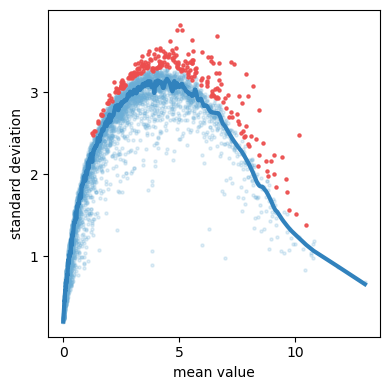

In [77]:
st.select_variable_genes(adata)

feature var_genes is being used ...
4 cpus are being used ...


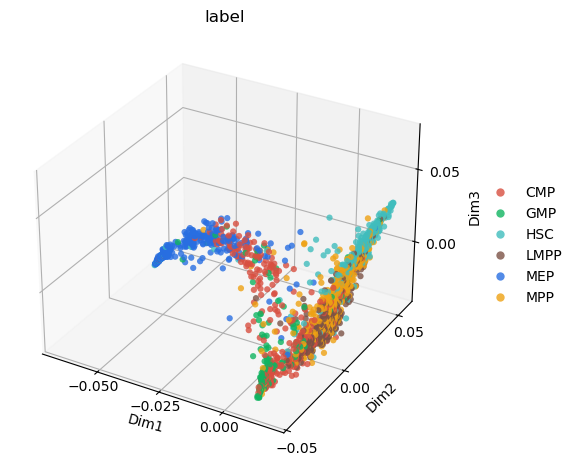

In [78]:
st.dimension_reduction(
    adata,
    method="mlle",
    feature="var_genes",
    n_components=3,
    n_neighbors=50,
    n_jobs=4
)
st.plot_dimension_reduction(adata)


In [79]:
#workaround the expired STREAM version
import networkx as nx

nx.Graph.node = property(lambda G: G._node)
nx.DiGraph.node = property(lambda G: G._node)
nx.MultiGraph.node = property(lambda G: G._node)
nx.MultiDiGraph.node = property(lambda G: G._node)

print(nx.__version__)
print("G.node compatibility:", hasattr(nx.Graph(), "node"))

st.seed_elastic_principal_graph(
    adata,
    clustering="ap",
    damping=0.75,
    pref_perc=50
)

2.5
G.node compatibility: True
Seeding initial elastic principal graph...
Clustering...
Affinity propagation ...
The number of initial nodes is 21
Calculatng minimum spanning tree...
Number of initial branches: 7


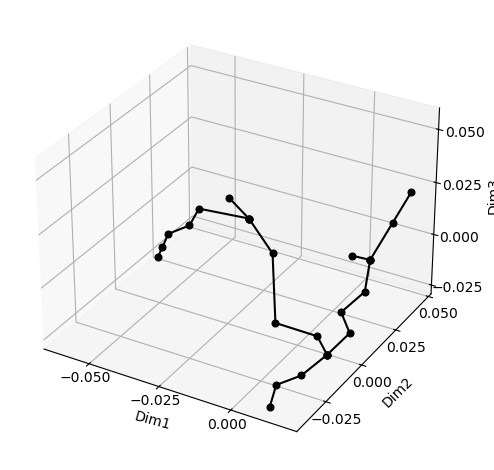

In [80]:
st.plot_branches(adata)

In [81]:
st.elastic_principal_graph(adata)

epg_n_nodes is too small. It is corrected to the initial number of nodes plus incr_n_nodes
Learning elastic principal graph...
[1] "Constructing tree 1 of 1 / Subset 1 of 1"
[1] "Computing EPG with 51 nodes on 1656 points and 3 dimensions"
[1] "Using a single core"
Nodes = 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 
BARCODE	ENERGY	NNODES	NEDGES	NRIBS	NSTARS	NRAYS	NRAYS2	MSE	MSEP	FVE	FVEP	UE	UR	URN	URN2	URSD
3||51	7.311e-05	51	50	43	3	0	0	3.383e-05	3.131e-05	0.9813	0.9827	3.595e-05	3.326e-06	0.0001696	0.008651	0
4.493 sec elapsed
[[1]]
Ignoring unknown labels:
• linetype : ""

TYPE epg_obj: <class 'rpy2.rlike.container.NamedList'>
TYPE epg_obj[0]: <class 'rpy2.rlike.container.NamedList'>
epg_obj[0]: <rpy2.rlike.container.NamedList object at 0x2b56d21a0>
NAMES epg_obj[0]: <bound method NamedList.names of <rpy2.rlike.container.NamedList object at 0x2b56d21a0>>
Number of branches after learning elastic principal graph: 7


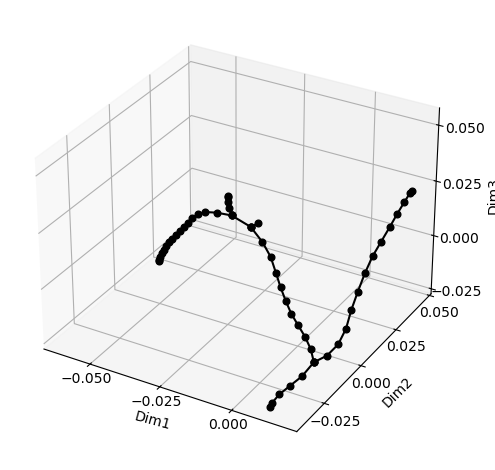

In [82]:
st.plot_branches(adata)


Optimizing branching...
[1] "Constructing tree 1 of 1 / Subset 1 of 1"
[1] "Computing EPG with 81 nodes on 1656 points and 3 dimensions"
[1] "Using a single core"
Nodes = 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 
BARCODE	ENERGY	NNODES	NEDGES	NRIBS	NSTARS	NRAYS	NRAYS2	MSE	MSEP	FVE	FVEP	UE	UR	URN	URN2	URSD
3||81	5.567e-05	81	80	73	3	0	0	2.838e-05	2.698e-05	0.9843	0.9851	2.488e-05	2.416e-06	0.0001957	0.01585	0
2.102 sec elapsed
Number of branches after optimizing branching: 7


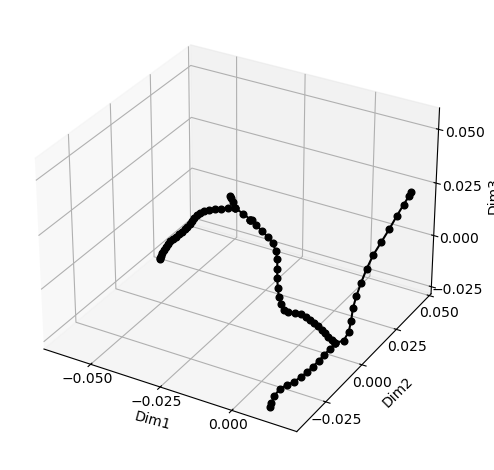

In [83]:
st.optimize_branching(adata,reset=True)
st.plot_branches(adata)

Extending leaves with additional nodes ...
Number of branches after extending leaves: 7


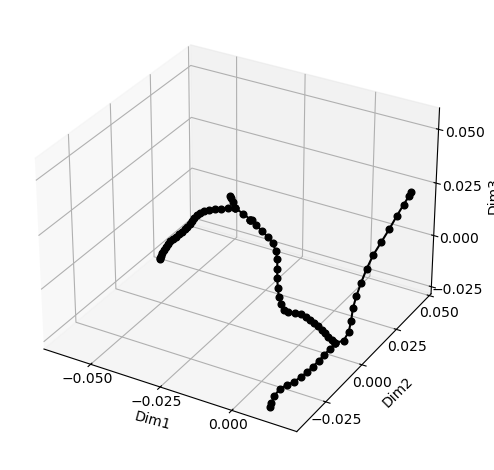

In [84]:
st.extend_elastic_principal_graph(adata)
st.plot_branches(adata)


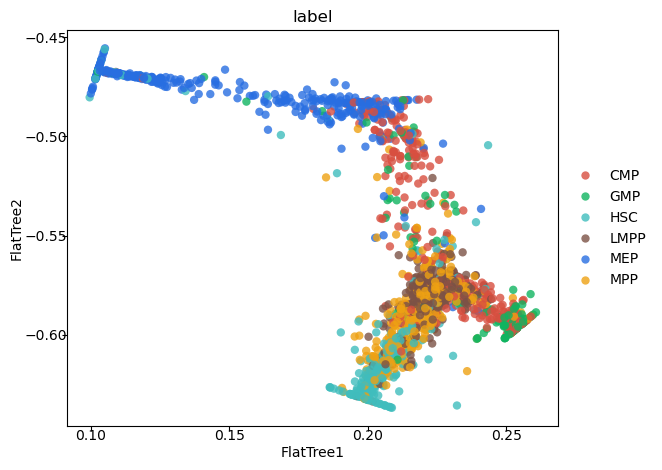

In [85]:
st.plot_flat_tree(adata)

/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


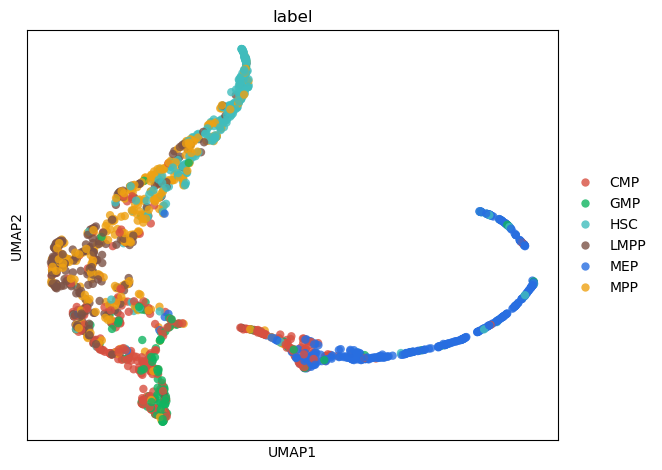

In [86]:
st.plot_visualization_2D(adata,use_precomputed=False)

/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


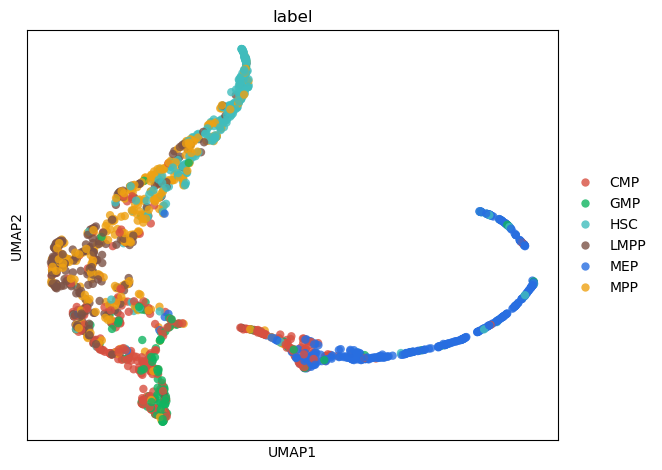

In [87]:
st.plot_visualization_2D(adata,use_precomputed=False)

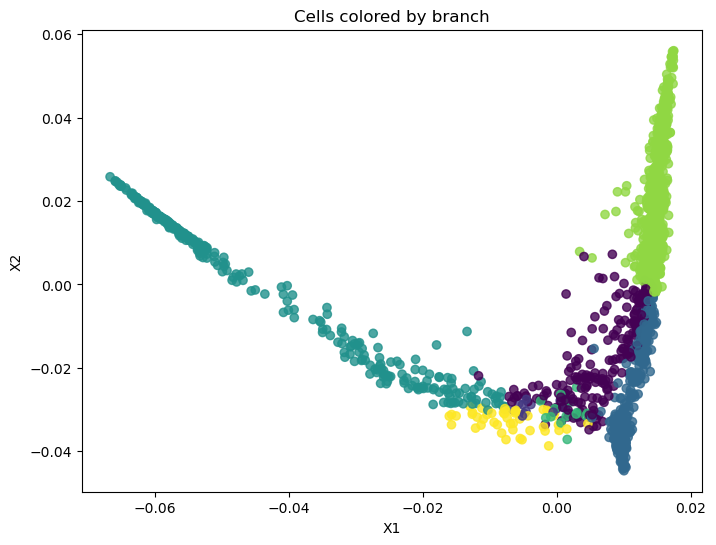

In [90]:
#workaround to plot with branch coloring 
import matplotlib.pyplot as plt
import pandas as pd

branch_codes = pd.Categorical(adata.obs["branch_id"]).codes

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    adata.obsm["X_dr"][:, 0],
    adata.obsm["X_dr"][:, 1],
    c=branch_codes,
    alpha=0.8
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Cells colored by branch")

plt.show()

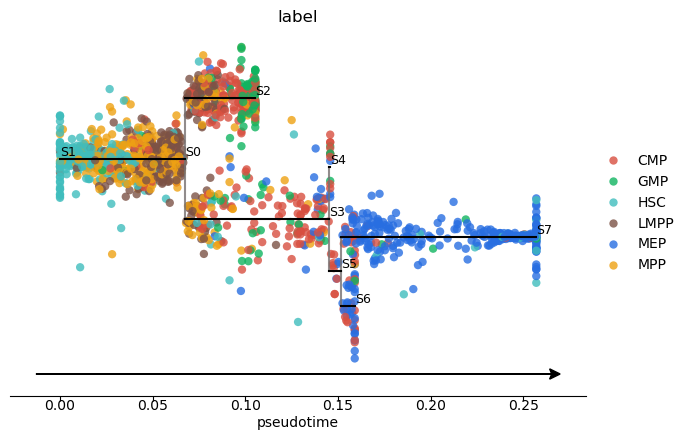

In [92]:
#problem: I have 7 nodes when the OG is 5 nodes
st.plot_stream_sc(
    adata,
    root="S1"
)

I have MORE nodes which is why the following stream plot has a weird rendering as the nodes are too close together

/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/extra.py:1008: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_edge_cellnum[edge_i][cell_i] = float(df_edge_i[df_edge_i['CELL_LABEL']==cell_i].shape[0])
/Use

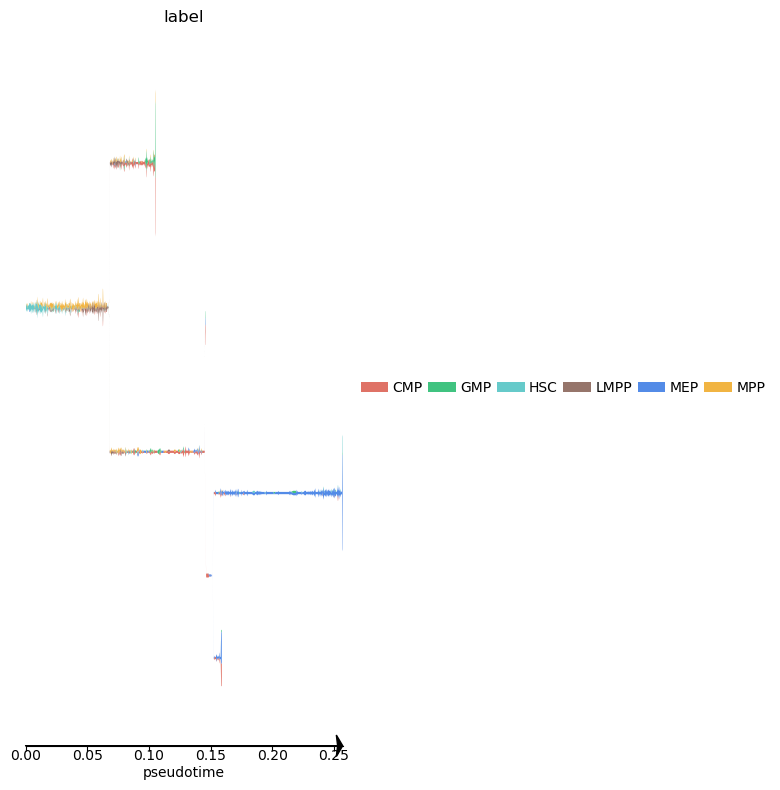

In [93]:
st.plot_stream(
    adata,
    root='S1',
    fig_size=(8, 8),
    fig_legend_ncol=6
)

In [96]:
#get a look at EPG edges
print("EPG edges:")
for a, b in adata.uns["epg"].edges():
    label_a = adata.uns["epg"].nodes[a].get("label", a)
    label_b = adata.uns["epg"].nodes[b].get("label", b)
    print(label_a, "--", label_b)

EPG edges:
0 -- 14
0 -- 18
1 -- 13
1 -- 14
2 -- 13
2 -- 22
3 -- 7
3 -- 47
4 -- 50
4 -- 78
4 -- 79
5 -- 10
5 -- 45
6 -- 8
6 -- 26
7 -- 17
8 -- 19
9 -- 15
9 -- 16
10 -- 68
10 -- 76
11 -- 12
11 -- 29
12 -- 34
15 -- 42
16 -- 21
17 -- 25
18 -- 23
19 -- 52
20 -- 26
20 -- 40
21 -- 27
22 -- 28
23 -- 38
24 -- 25
24 -- 51
27 -- 33
28 -- 30
29 -- 53
30 -- 35
31 -- 40
31 -- 43
32 -- 43
32 -- 57
33 -- 37
34 -- 36
35 -- 48
37 -- 44
38 -- 50
39 -- 42
39 -- 47
41 -- 46
41 -- 68
41 -- 80
45 -- 49
51 -- 55
52 -- 54
53 -- 59
54 -- 56
55 -- 58
56 -- 61
57 -- 60
58 -- 64
59 -- 62
60 -- 63
61 -- 70
62 -- 65
63 -- 66
64 -- 67
65 -- 71
66 -- 69
67 -- 72
69 -- 73
70 -- 80
71 -- 75
72 -- 74
73 -- 77
74 -- 76
75 -- 78
77 -- 79


Expected result from OG paper:OG
![STREAM trajectory](/Users/alicedecugis/Desktop/OG.png)

#### The order between horizontal branches from the same parent node has no meaning

#### Users can specify the order preference of nodes themselves

/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/extra.py:1008: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_edge_cellnum[edge_i][cell_i] = float(df_edge_i[df_edge_i['CELL_LABEL']==cell_i].shape[0])
/Use

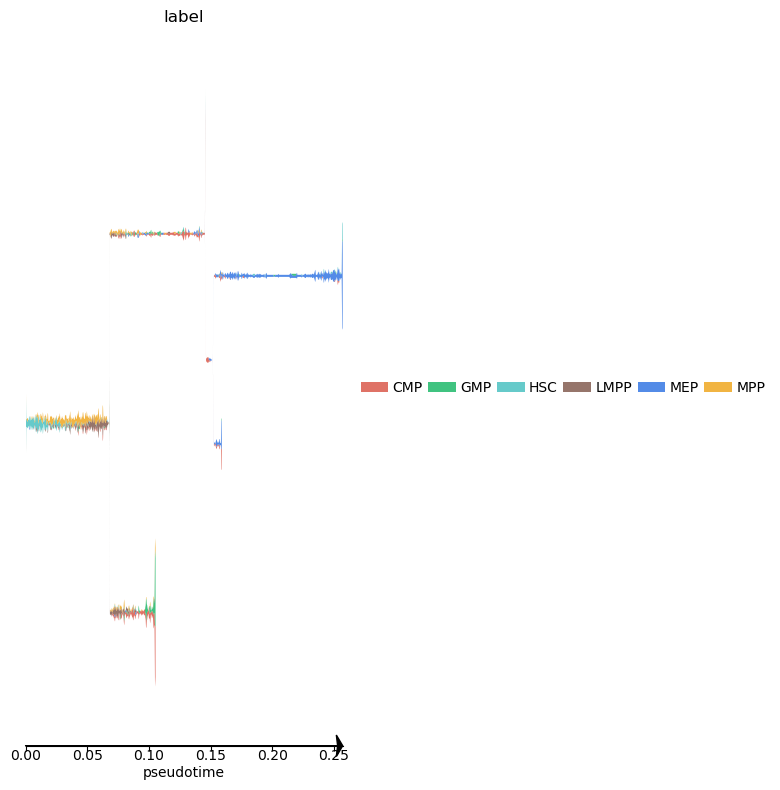

In [102]:
st.plot_stream(
    adata,
    root='S1',
    fig_legend_ncol=6,
    fig_size=(8, 8),
    factor_min_win=1.2,
    preference=['S4', 'S5']
)

In [104]:
#detect all existing functions in my version of stream:
[x for x in dir(st) if "transition" in x.lower()]

['detect_transition_markers', 'plot_transition_markers']

In [105]:
st.detect_transition_markers(adata,root='S1',preference=['S4','S5'])

Scanning all features ...
Filtering out markers that are expressed in less than 5 cells ...


/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3376: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_marker_detection[input_markers_expressed] = df_sc[input_markers_expressed].copy()
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3376: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_marker_detection[input_markers_expressed] = df_sc[input_markers_expressed].copy()
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/st

1 cpus are being used ...


/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3376: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_marker_detection[input_markers_expressed] = df_sc[input_markers_expressed].copy()
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3376: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_marker_detection[input_markers_expressed] = df_sc[input_markers_expressed].copy()
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/st

4767 markers are being scanned ...


/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3420: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  df_stat_pval_qval.loc[markername,['stat','pval']] = spearmanr(df_cells_edge_i_sort.loc[:,markername],\
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3420: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  df_stat_pval_qval.loc[markername,['stat','pval']] = spearmanr(df_cells_edge_i_sort.loc[:,markername],\
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3420: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  df_stat_pval_qval.loc[markername,['stat','pval']] = spearmanr(df_cells_edge_i_sort.loc[:,markername],\
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3420: ConstantInputWa

/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3471: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if(stat[i]>0):
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3476: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "{:.2E}".format(Decimal(str(qvals[i]))),size=0.8*mpl.rcParams['font.size'],
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3483: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consis

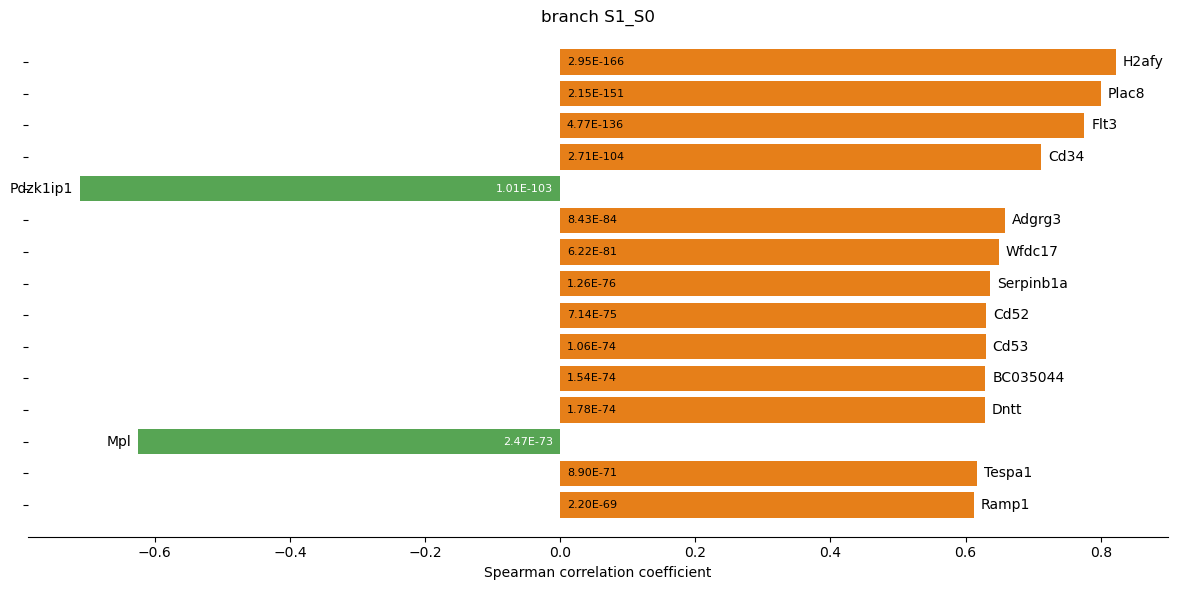

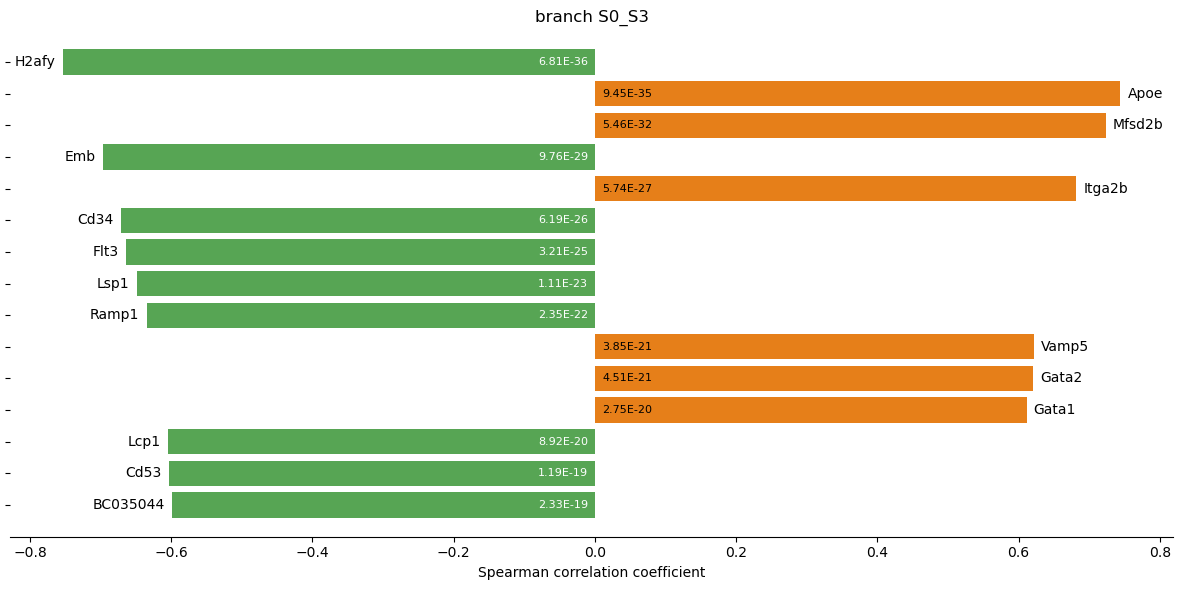

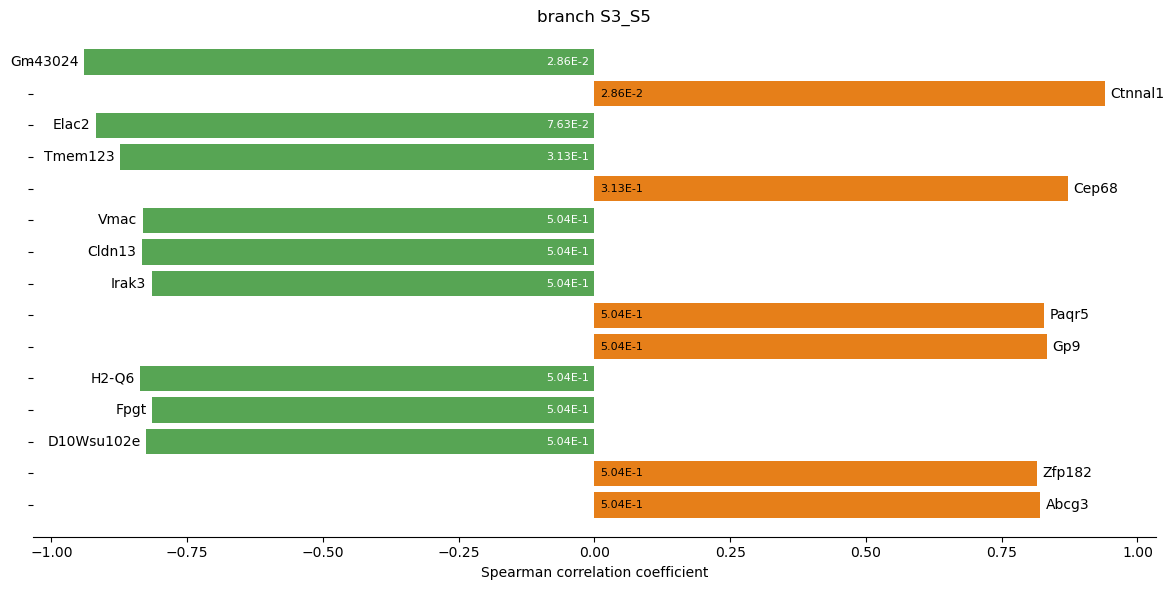

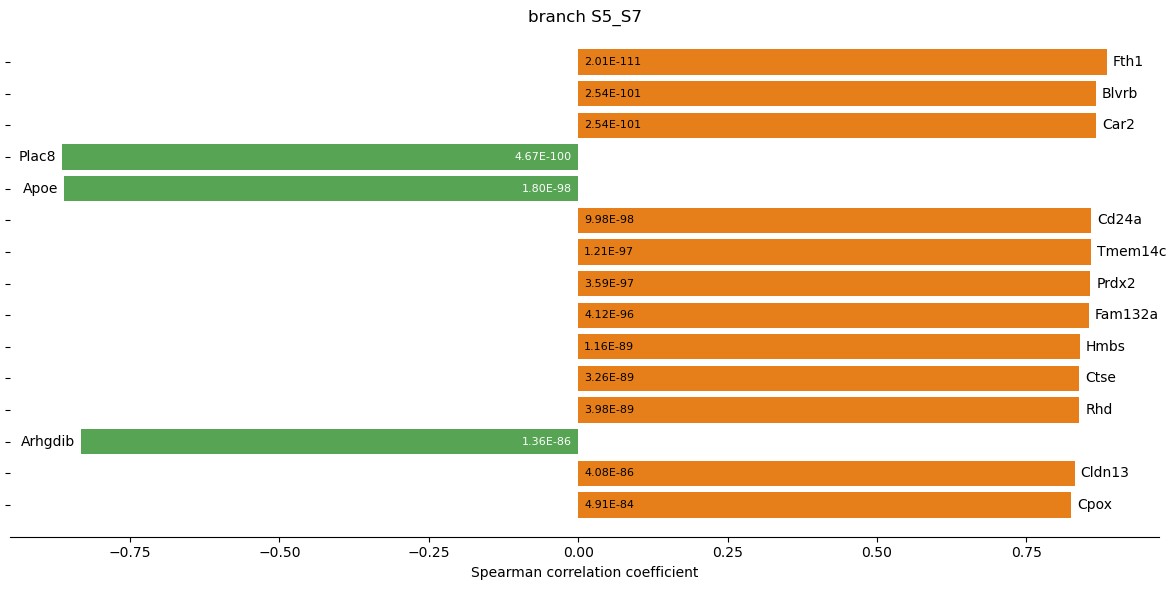

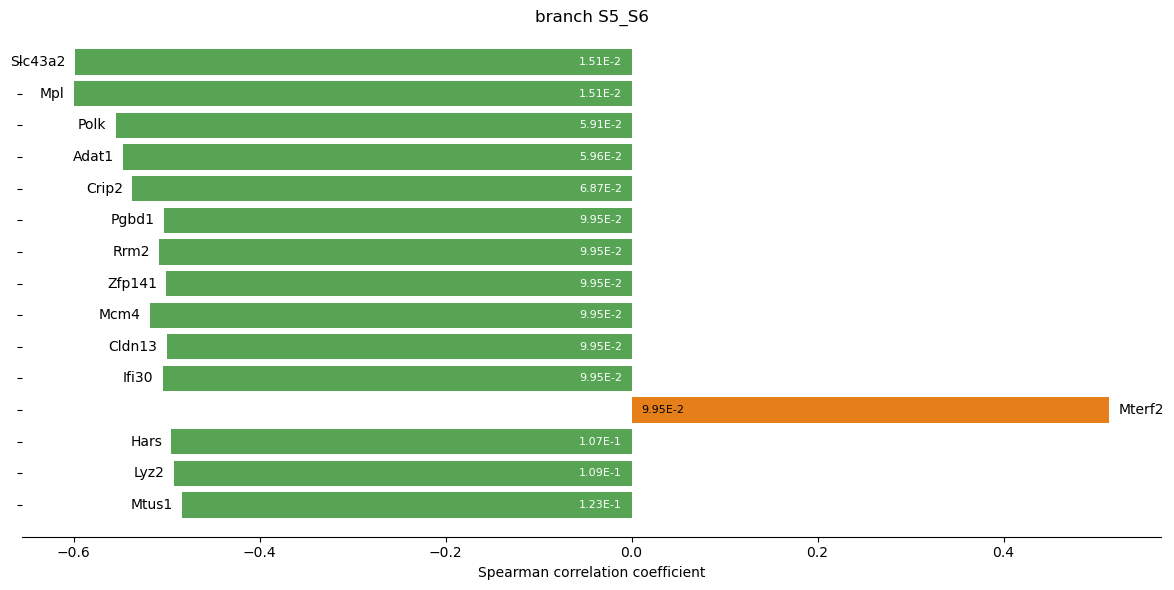

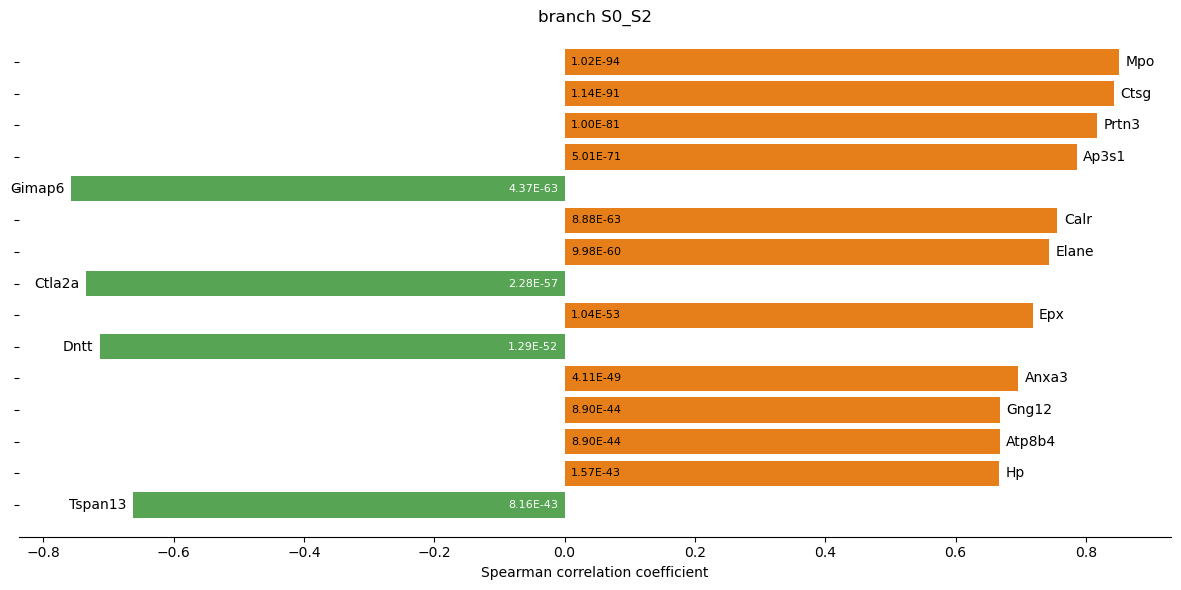

In [111]:
tm = adata.uns["transition_markers"]

adata.uns["transition_markers"] = {
    k: v for k, v in tm.items()
    if len(v) > 0
}

st.plot_transition_markers(adata)

In [109]:
print(adata.uns.keys())
print(type(adata.uns["transition_markers"]))
print(adata.uns["transition_markers"])
if hasattr(adata.uns["transition_markers"], "keys"):
    print(adata.uns["transition_markers"].keys())
print(adata.uns["transition_markers"])

odict_keys(['workdir', 'label_color', 'var_genes', 'trans_mlle', 'params', 'epg', 'flat_tree', 'seed_epg', 'seed_flat_tree', 'ori_epg', 'epg_obj', 'ori_epg_obj', 'vis_trans_umap', 'stream_S1', 'scaled_marker_expr', 'transition_markers'])
<class 'dict'>
{('S1', 'S0'):               stat     logfc           pval           qval
H2afy     0.822400  0.586511  1.043839e-169  2.953020e-166
Plac8     0.800988  1.322524  1.519098e-154  2.148764e-151
Flt3      0.775972  1.972351  5.061970e-139  4.773438e-136
Cd34      0.712043  0.958669  3.830576e-107  2.709175e-104
Pdzk1ip1 -0.710479  1.861498  1.790849e-106  1.013263e-103
...            ...       ...            ...            ...
Dock10    0.405581  1.063907   1.511679e-28   7.248374e-27
Csf3r     0.404512  1.039235   2.159676e-28   1.018287e-26
Rab38    -0.401785  0.577581   5.337365e-28   2.475312e-26
Cish     -0.401675  2.017334   5.534182e-28   2.525194e-26
Itgal     0.400859  2.379442   7.242340e-28   3.252156e-26

[63 rows x 4 columns], 

In [110]:
tm = adata.uns["transition_markers"]

print(type(tm))
print(tm)

<class 'dict'>
{('S1', 'S0'):               stat     logfc           pval           qval
H2afy     0.822400  0.586511  1.043839e-169  2.953020e-166
Plac8     0.800988  1.322524  1.519098e-154  2.148764e-151
Flt3      0.775972  1.972351  5.061970e-139  4.773438e-136
Cd34      0.712043  0.958669  3.830576e-107  2.709175e-104
Pdzk1ip1 -0.710479  1.861498  1.790849e-106  1.013263e-103
...            ...       ...            ...            ...
Dock10    0.405581  1.063907   1.511679e-28   7.248374e-27
Csf3r     0.404512  1.039235   2.159676e-28   1.018287e-26
Rab38    -0.401785  0.577581   5.337365e-28   2.475312e-26
Cish     -0.401675  2.017334   5.534182e-28   2.525194e-26
Itgal     0.400859  2.379442   7.242340e-28   3.252156e-26

[63 rows x 4 columns], ('S0', 'S3'):               stat     logfc          pval          qval
H2afy    -0.753452  0.377542  2.253360e-39  6.809655e-36
Apoe      0.744020  1.193619  6.256169e-38  9.453071e-35
Mfsd2b    0.723459  1.655228  5.416760e-35  5.456483e